## **3. KMeans on PCA Space**

## **3.1 Imports**

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.append(str(ROOT))

In [2]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns 

from typing import Iterable, Tuple, List

from sklearn.decomposition  import PCA
from sklearn.cluster        import KMeans
from sklearn.metrics        import silhouette_score, adjusted_rand_score, confusion_matrix


from src.clustering.plots   import plot_clusters_pca, plot_inertia_silhouette_vs_k
from src.clustering.metrics import silhouette_by_cluster

## **3.2 Load Data**

In [3]:
X = pd.read_parquet('../data/processed/X_genotypes.parquet').values
y = pd.read_csv('../data/processed/y_clades.csv').squeeze()
snp_info = pd.read_csv('../data/processed/snp_info.csv')
sample_meta_info = pd.read_csv('../data/processed/sample_meta.csv')

## **3.3 Elbow Rule: Inertia vs k**

In [4]:
pca = PCA(n_components=4, random_state=42)

Z = pca.fit_transform(X)

(<Figure size 700x400 with 2 Axes>,
 (<Axes: title={'center': 'Elbow (Inertia) + Silhouette vs k'}, xlabel='k', ylabel='Inertia'>,
  <Axes: ylabel='Silhouette score'>))

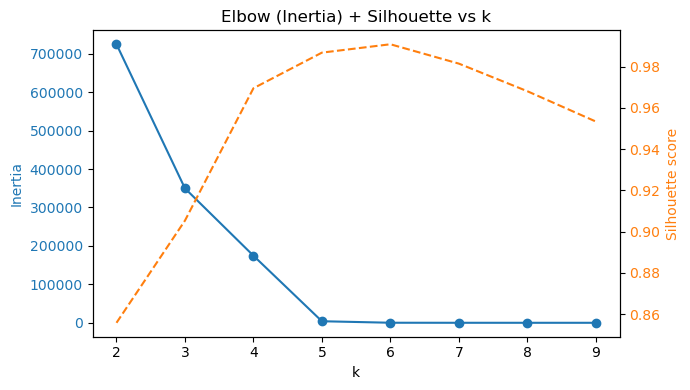

In [5]:
plot_inertia_silhouette_vs_k(Z, ks=range(2, 10))

Nota-se que em k=6 os clusters estão compactos (baixa inércia) e bem separados entre sí (silhouette ~ 1.0)

## **3.4 KMeans on PCA Space**

In [6]:
km = KMeans(n_clusters=6, random_state=42)
cluster_labels = km.fit_predict(Z)

## **3.5 Scatter Plot with Centroids**

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Cluster centroids in PCA space'}, xlabel='PC1', ylabel='PC3'>)

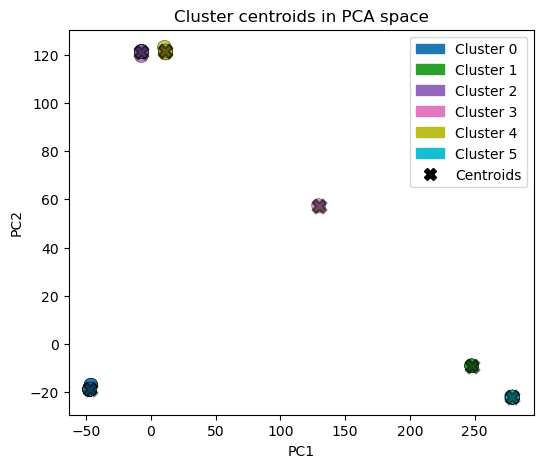

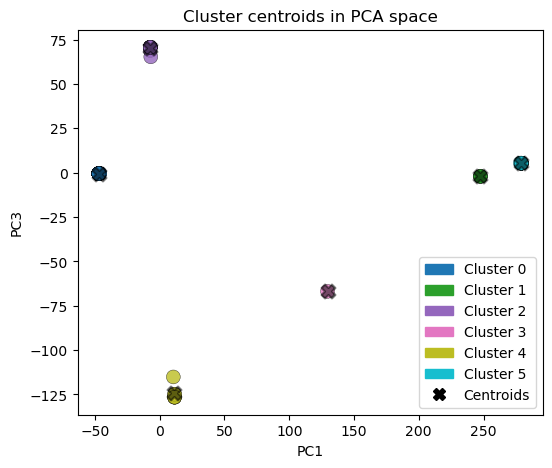

In [7]:
plot_clusters_pca(Z, cluster_labels, pca_idxs=(0, 1))
plot_clusters_pca(Z, cluster_labels, pca_idxs=(0, 2))

## **3.6 Silhouette per Cluster**

In [8]:
silhouette_by_cluster(Z, cluster_labels)

,mean,median,std,count
cluster,,,,
0,0.999168,0.999483,0.001765,113
1,0.999780,0.999811,0.000073,3
2,0.992503,0.995629,0.008492,13
3,0.000000,0.000000,NaN,1
4,0.979808,0.986928,0.017202,7
5,0.996167,0.997615,0.004846,16


Notavelmente cada cluster individual tem boa separação dos demais.

In [9]:
y.value_counts()

clade
I      113
III     13
MG       8
IV       8
II       7
VI       3
V        1
Name: count, dtype: int64

## **3.7 Confusion Matrix: K-Means labels vs labels from literature**

In [10]:
ari = adjusted_rand_score(y, cluster_labels)
print(f'Adjusted Rand Index: {ari:.4f}')

Adjusted Rand Index: 0.9888


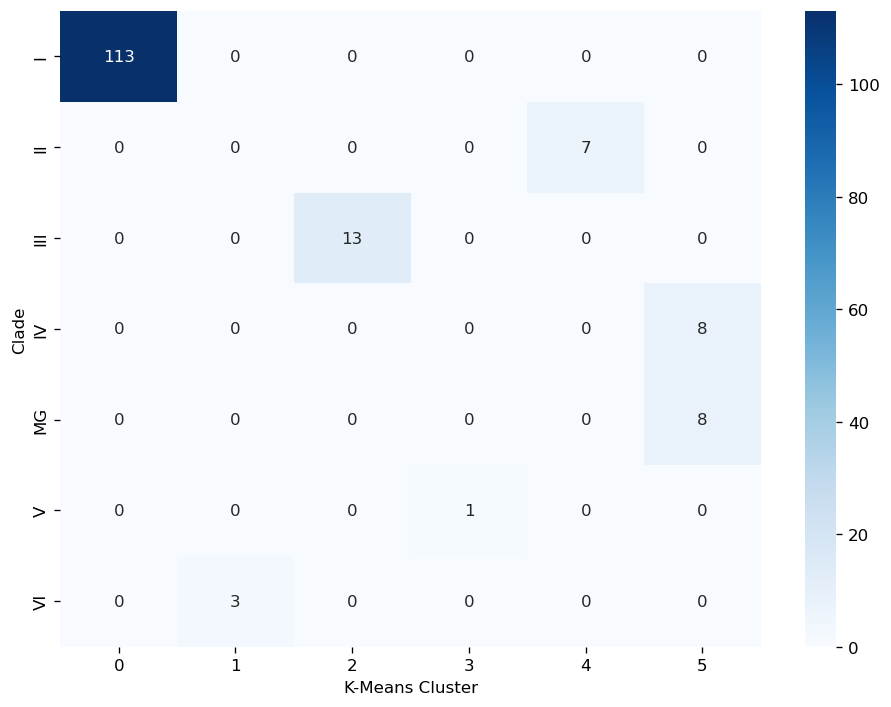

In [11]:
ct = pd.crosstab(y, cluster_labels, rownames=['Clade'], colnames=['K-Means Cluster'])

fig, ax = plt.subplots(figsize=(8, 6), dpi=120)
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax)
fig.tight_layout()
plt.show()

## **3.8 Biological Interpretation of Clusters**

In [12]:
meta_df = pd.DataFrame({
    'cluster': cluster_labels,
    'country': sample_meta_info['country'].values,
    'year': sample_meta_info['year'].values,
})



In [13]:
# Distribuição geográfica por cluster
meta_df.groupby('cluster')['country'].value_counts()

cluster  country             
0        lebanon                 28
         saudi_arabia            22
         hong_kong               19
         usa                     13
         italy                   10
         germany                  6
         china                    4
         pakistan                 2
         india                    2
         poland                   1
         egypt                    1
         united_arab_emirates     1
         russia                   1
2        china                    5
         south_africa             3
         usa                      2
         ai_china                 1
         canada                   1
         case_china               1
3        iran                     1
4        japan                    3
         usa                      2
         south_korea              1
         canada                   1
5        brazil                   8
         venezuela                3
         mexico                   

In [14]:
# Ano médio por cluster
meta_df.groupby('cluster')['year'].agg(['min', 'max', 'mean'])

,min,max,mean
cluster,,,
0,2008.0,2023.0,2019.333333
1,2018.0,2023.0,2021.000000
2,2012.0,2023.0,2018.000000
3,2018.0,2018.0,2018.000000
4,2004.0,2016.0,2009.500000
5,2012.0,2024.0,2020.133333


### **3.8.3 Assinatura Genômica por Cluster**

Para cada cluster identificado pelo K-Means, buscamos quais SNPs — e quais substituições de base — são mais característicos. A estratégia é calcular a média do genótipo (0–2) de cada SNP por cluster e selecionar os que apresentam maior variância entre clusters.

In [ ]:
transition_info = pd.read_csv('../data/processed/transition_info.csv')

# Média do genótipo por SNP por cluster
cluster_means = pd.DataFrame(X).groupby(cluster_labels).mean()  # shape: (6, 272578)

# SNPs com maior variância entre clusters → mais discriminantes
N = 20
inter_cluster_var = cluster_means.var(axis=0)
top_snp_idx = inter_cluster_var.nlargest(N).index.tolist()

# Anotação: ref→alt + cromossomo + posição
def chrom_short(c):
    return 'chr' + c.split('_')[1].split('.')[0][-2:]

top_snps_bio = pd.DataFrame({
    'ref':  transition_info.iloc[top_snp_idx]['ref'].values,
    'alt':  transition_info.iloc[top_snp_idx]['alt'].values,
    'chrom': snp_info.iloc[top_snp_idx]['chrom'].apply(chrom_short).values,
    'pos':  snp_info.iloc[top_snp_idx]['pos'].values,
})
top_snps_bio['label'] = top_snps_bio.apply(
    lambda r: f"{r['ref']}→{r['alt']}  {r['chrom']}:{r['pos']}", axis=1
)

top_snps_bio

In [ ]:
heatmap_df = cluster_means[top_snp_idx].copy()
heatmap_df.columns = top_snps_bio['label'].values

fig, ax = plt.subplots(figsize=(20, 4))
sns.heatmap(
    heatmap_df,
    annot=True, fmt='.2f',
    cmap='YlOrRd', vmin=0, vmax=2,
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'Média do genótipo (0–2)'},
)
ax.set_xlabel('SNP (ref→alt  cromossomo:posição)', labelpad=10)
ax.set_ylabel('Cluster K-Means')
ax.set_title(f'Top {N} SNPs com maior variância entre clusters')
fig.tight_layout()
plt.show()

In [ ]:
# SNPs específicos de cada cluster: alto naquele cluster, baixo nos demais
rows = []
for cid in sorted(cluster_means.index):
    other_max = cluster_means.drop(index=cid).max(axis=0)
    specificity = cluster_means.loc[cid] - other_max
    top5_idx = specificity.nlargest(5).index.tolist()
    for rank, snp_i in enumerate(top5_idx, 1):
        rows.append({
            'cluster':       cid,
            'rank':          rank,
            'ref':           transition_info.iloc[snp_i]['ref'],
            'alt':           transition_info.iloc[snp_i]['alt'],
            'chrom':         chrom_short(snp_info.iloc[snp_i]['chrom']),
            'pos':           snp_info.iloc[snp_i]['pos'],
            'mean_cluster':  round(cluster_means.loc[cid, snp_i], 3),
            'mean_others':   round(other_max[snp_i], 3),
        })

signature_df = pd.DataFrame(rows)
signature_df

## **3.9 Conclusion**

O processo de clusterização via K-Means aponta que as 8 amostras colhidas em MG devem pertencer ao clado IV, portanto, vamos atualizar os labels adequando os clados corretamente:

In [15]:
y = y.replace('MG', 'IV')

In [16]:
np.unique(y)

array(['I', 'II', 'III', 'IV', 'V', 'VI'], dtype=object)

In [17]:
y.to_csv('../data/processed/y_clades_kmeans.csv', index=False)